# Feature Engineering

In [167]:
cus_segment["Churn Binary"].value_counts()

Churn Binary
0    5174
1    1869
Name: count, dtype: int64

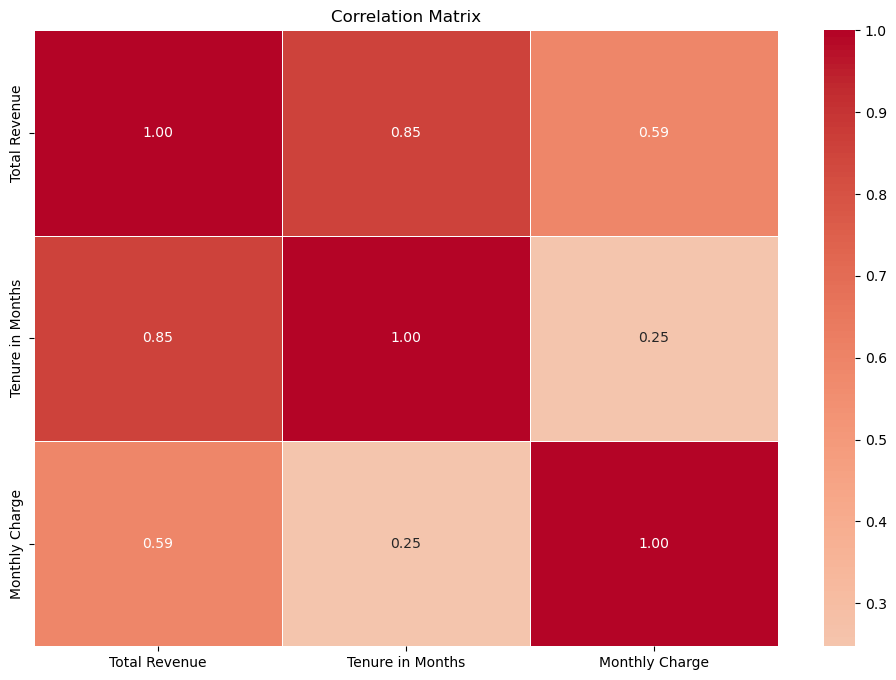

In [168]:
plt.figure(figsize=(12,8))
sb.heatmap(correv,
           annot=True,
           fmt=".2f",
           cmap="coolwarm",
           center=0,
           linewidths=0.5)

plt.title("Correlation Matrix")
plt.show()


## Churn Score is usually generated using churn behavior. It leaks target information.
## CLTV Customer Lifetime Value depends on churn
## Total Revenue ≈ Monthly Charge × Tenure So it indirectly contains: How long the customer stayed How much they already paid
## But churn risk is strongly related to tenure 
## if you already have: Tenure and Monthly Charge Then Total Revenue becomes redundant.

In [169]:
## Excluding non-informative and data leakage features prior to model development

drop_cols = ["Customer ID",
             "Country",
             "State",
             "City",
             "Zip Code",
             "Latitude",
             "Longitude",
             "Customer Status",
             "Churn Score",
             "Churn Category",
             "Churn Reason",
             "CLTV",
             "Total Revenue",
             "Total Charges",
             "Total Refunds",
             "Total Extra Data Charges",
             "Total Long Distance Charges",
             "tenure_cut",
             "Revenue Bucket",
             "Age Group",
             "Under 30",
             "Senior Citizen",
             "Dependents",
             "cluster"]

ib_model = ibdata.drop(columns=drop_cols)

In [170]:
ib_model.head()

,Gender,Age,Married,Number of Dependents,Population,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Satisfaction Score,Churn Label,Churn Binary,GB_Group,AddOn_Count,City_Grouped,Streaming_Count
0,Male,78,No,0,68701,Q3,No,0,1,NaN,No,0.00,0,Yes,DSL,8,No,No,Yes,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,3,Yes,1,Medium,1,Los Angeles,1
1,Female,74,Yes,1,55668,Q3,Yes,1,8,Offer E,Yes,48.85,1,Yes,Fiber Optic,17,No,Yes,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,3,Yes,1,Medium,1,Los Angeles,0
2,Male,71,No,3,47534,Q3,No,0,18,Offer D,Yes,11.33,1,Yes,Fiber Optic,52,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,2,Yes,1,Very High,0,Los Angeles,3
3,Female,78,Yes,1,27778,Q3,Yes,1,25,Offer C,Yes,19.76,0,Yes,Fiber Optic,12,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2,Yes,1,Medium,2,Other,2
4,Female,80,Yes,1,26265,Q3,Yes,1,37,Offer C,Yes,6.33,1,Yes,Fiber Optic,14,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2,Yes,1,Medium,0,Whittier,0


In [171]:
num_cols_dr = ib_model.select_dtypes(include=['number']).columns.tolist()
cat_cols_dr = ib_model.select_dtypes(include=['object']).columns.tolist()

In [172]:
print(*ib_model.columns, sep="\n")

Gender
Age
Married
Number of Dependents
Population
Quarter
Referred a Friend
Number of Referrals
Tenure in Months
Offer
Phone Service
Avg Monthly Long Distance Charges
Multiple Lines
Internet Service
Internet Type
Avg Monthly GB Download
Online Security
Online Backup
Device Protection Plan
Premium Tech Support
Streaming TV
Streaming Movies
Streaming Music
Unlimited Data
Contract
Paperless Billing
Payment Method
Monthly Charge
Satisfaction Score
Churn Label
Churn Binary
GB_Group
AddOn_Count
City_Grouped
Streaming_Count


In [173]:
## Number int columns after drop

num_cols_dr

['Age',
 'Number of Dependents',
 'Population',
 'Number of Referrals',
 'Tenure in Months',
 'Avg Monthly Long Distance Charges',
 'Multiple Lines',
 'Avg Monthly GB Download',
 'Monthly Charge',
 'Satisfaction Score',
 'Churn Binary',
 'AddOn_Count',
 'Streaming_Count']

# Null Handling

In [174]:
for i in num_cols_dr:
    print(f"The null values of column  {i} is {ib_model[i].isnull().sum()}")

The null values of column  Age is 0
The null values of column  Number of Dependents is 0
The null values of column  Population is 0
The null values of column  Number of Referrals is 0
The null values of column  Tenure in Months is 0
The null values of column  Avg Monthly Long Distance Charges is 0
The null values of column  Multiple Lines is 0
The null values of column  Avg Monthly GB Download is 0
The null values of column  Monthly Charge is 0
The null values of column  Satisfaction Score is 0
The null values of column  Churn Binary is 0
The null values of column  AddOn_Count is 0
The null values of column  Streaming_Count is 0


In [175]:
## category object columns after drop

cat_cols_dr

['Gender',
 'Married',
 'Quarter',
 'Referred a Friend',
 'Offer',
 'Phone Service',
 'Internet Service',
 'Internet Type',
 'Online Security',
 'Online Backup',
 'Device Protection Plan',
 'Premium Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Streaming Music',
 'Unlimited Data',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Churn Label',
 'City_Grouped']

In [176]:
for i in cat_cols_dr:
    print(f"The null values of column  {i} is {ib_model[i].isnull().sum()}")

The null values of column  Gender is 0
The null values of column  Married is 0
The null values of column  Quarter is 0
The null values of column  Referred a Friend is 0
The null values of column  Offer is 3877
The null values of column  Phone Service is 0
The null values of column  Internet Service is 0
The null values of column  Internet Type is 1526
The null values of column  Online Security is 0
The null values of column  Online Backup is 0
The null values of column  Device Protection Plan is 0
The null values of column  Premium Tech Support is 0
The null values of column  Streaming TV is 0
The null values of column  Streaming Movies is 0
The null values of column  Streaming Music is 0
The null values of column  Unlimited Data is 0
The null values of column  Contract is 0
The null values of column  Paperless Billing is 0
The null values of column  Payment Method is 0
The null values of column  Churn Label is 0
The null values of column  City_Grouped is 0


In [177]:
## NULL Sum of columns Offer

len(ib_model) - ib_model["Offer"].isnull().sum()

np.int64(3166)

In [178]:
## Null Percentage of Offer

(len(ib_model) - ib_model["Offer"].isnull().sum())/len(ib_model)*100

np.float64(44.95243504188556)

In [179]:
## NULL Sum of columns Internet Type

(len(ib_model) - ib_model["Internet Type"].isnull().sum())

np.int64(5517)

In [180]:
## Null Percentage of Internet Type

(len(ib_model) - ib_model["Internet Type"].isnull().sum())/len(ib_model)*100

np.float64(78.33309669175067)

In [181]:
## Filling Offer column with No offer as this column means it

ib_model["Offer"] = ib_model["Offer"].fillna("No Offer")

In [182]:
## Filling Internet Type column with No Internet as this column means it

ibdata["Internet Type"] = ibdata["Internet Type"].fillna("No Internet")

In [183]:
for i in cat_cols_dr:
    print(f"The null values of column  {i} is {ib_model[i].isnull().sum()}")

The null values of column  Gender is 0
The null values of column  Married is 0
The null values of column  Quarter is 0
The null values of column  Referred a Friend is 0
The null values of column  Offer is 0
The null values of column  Phone Service is 0
The null values of column  Internet Service is 0
The null values of column  Internet Type is 1526
The null values of column  Online Security is 0
The null values of column  Online Backup is 0
The null values of column  Device Protection Plan is 0
The null values of column  Premium Tech Support is 0
The null values of column  Streaming TV is 0
The null values of column  Streaming Movies is 0
The null values of column  Streaming Music is 0
The null values of column  Unlimited Data is 0
The null values of column  Contract is 0
The null values of column  Paperless Billing is 0
The null values of column  Payment Method is 0
The null values of column  Churn Label is 0
The null values of column  City_Grouped is 0


In [184]:
uni(cat_cols_dr)

The unique values of column Gender are ['Male' 'Female']
----------------------------------------------------------------------------------------------------
The unique values of column Married are ['No' 'Yes']
----------------------------------------------------------------------------------------------------
The unique values of column Quarter are ['Q3']
----------------------------------------------------------------------------------------------------
The unique values of column Referred a Friend are ['No' 'Yes']
----------------------------------------------------------------------------------------------------
The unique values of column Offer are [nan 'Offer E' 'Offer D' 'Offer C' 'Offer B' 'Offer A']
----------------------------------------------------------------------------------------------------
The unique values of column Phone Service are ['No' 'Yes']
----------------------------------------------------------------------------------------------------
The unique values of 

In [185]:
## Quarter is unique as it is Q3 3rd Quater nothing to learn hence can be droped

ib_model = ib_model.drop(columns= "Quarter")

In [186]:
## Iam not making the Gender Bias but to make the learning better

ib_model["Gender"] = ib_model["Gender"].map({"Male":1, "Female":0})

In [187]:
binary_cols = ['Married','Referred a Friend','Phone Service',
'Internet Service','Online Security','Online Backup',
'Device Protection Plan','Premium Tech Support',
'Streaming TV','Streaming Movies','Streaming Music',
'Unlimited Data','Paperless Billing','Churn Label']

for col in binary_cols:
    ib_model[col] = ib_model[col].map({'Yes':1,'No':0})

In [188]:
cat_rem = ib_model.select_dtypes(include=['object']).columns.tolist()
cat_rem

['Offer', 'Internet Type', 'Contract', 'Payment Method', 'City_Grouped']

In [189]:
uni(cat_rem)

The unique values of column Offer are [nan 'Offer E' 'Offer D' 'Offer C' 'Offer B' 'Offer A']
----------------------------------------------------------------------------------------------------
The unique values of column Internet Type are ['DSL' 'Fiber Optic' 'Cable' 'No Internet']
----------------------------------------------------------------------------------------------------
The unique values of column Contract are ['Month-to-Month' 'One Year' 'Two Year']
----------------------------------------------------------------------------------------------------
The unique values of column Payment Method are ['Bank Withdrawal' 'Credit Card' 'Mailed Check']
----------------------------------------------------------------------------------------------------
The unique values of column City_Grouped are ['Los Angeles' 'Other' 'Whittier' 'Pasadena' 'San Diego' 'Riverside'
 'Temecula' 'Fresno' 'San Francisco' 'Berkeley' 'San Jose' 'Escondido'
 'Fallbrook' 'Long Beach' 'Glendale' 'Stockton' '

In [190]:
## Dummies for Offers Features

ib_model = pd.get_dummies(ib_model, columns=["Offer"], drop_first=True)

In [191]:
## Dummies for Internet type Features

ib_model = pd.get_dummies(ib_model, columns=["Internet Type"], drop_first=True)

In [192]:
ib_model = pd.get_dummies(ib_model, columns=["City_Grouped"], drop_first=True)

In [193]:
## Contract features mapped with Ordinal Type

ib_model["Contract"] = ib_model["Contract"].map({"Month-to-Month": 0,"One Year": 1,"Two Year": 2})

In [194]:
ib_model = pd.get_dummies(ib_model, columns=["Payment Method"], drop_first=True)

In [195]:
bool_cols = ib_model.select_dtypes(include=["bool", "uint8"]).columns

In [196]:
ib_model[bool_cols] = ib_model[bool_cols].astype(int)

In [197]:
ib_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 57 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   Gender                             7043 non-null   int64   
 1   Age                                7043 non-null   int64   
 2   Married                            7043 non-null   int64   
 3   Number of Dependents               7043 non-null   int64   
 4   Population                         7043 non-null   int64   
 5   Referred a Friend                  7043 non-null   int64   
 6   Number of Referrals                7043 non-null   int64   
 7   Tenure in Months                   7043 non-null   int64   
 8   Phone Service                      7043 non-null   int64   
 9   Avg Monthly Long Distance Charges  7043 non-null   float64 
 10  Multiple Lines                     7043 non-null   int64   
 11  Internet Service                   7043 non

In [198]:
pd.set_option('display.max_columns', None)

In [199]:
ib_model.describe()

,Gender,Age,Married,Number of Dependents,Population,Referred a Friend,Number of Referrals,Tenure in Months,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Monthly Charge,Satisfaction Score,Churn Label,Churn Binary,AddOn_Count,Streaming_Count,Offer_Offer A,Offer_Offer B,Offer_Offer C,Offer_Offer D,Offer_Offer E,Internet Type_DSL,Internet Type_Fiber Optic,City_Grouped_Berkeley,City_Grouped_Escondido,City_Grouped_Fallbrook,City_Grouped_Fresno,City_Grouped_Glendale,City_Grouped_Long Beach,City_Grouped_Los Angeles,City_Grouped_Oakland,City_Grouped_Other,City_Grouped_Pasadena,City_Grouped_Riverside,City_Grouped_Sacramento,City_Grouped_San Diego,City_Grouped_San Francisco,City_Grouped_San Jose,City_Grouped_Stockton,City_Grouped_Temecula,City_Grouped_Whittier,Payment Method_Credit Card,Payment Method_Mailed Check
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.504756,46.509726,0.483033,0.468692,22139.603294,0.457476,1.951867,32.386767,0.903166,22.958954,0.421837,0.783331,20.515405,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.353259,0.673719,0.754792,0.592219,64.761692,3.244924,0.265370,0.265370,1.265654,1.125515,0.073832,0.116996,0.058924,0.085475,0.114298,0.234559,0.430924,0.004544,0.007241,0.006105,0.008661,0.005679,0.008519,0.041602,0.007383,0.793554,0.004260,0.004544,0.015334,0.040466,0.014766,0.015902,0.006247,0.005395,0.004260,0.390317,0.054664
std,0.500013,16.750352,0.499748,0.962802,21152.392837,0.498224,3.001199,24.542061,0.295752,15.448113,0.493888,0.412004,20.418940,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.478016,0.468885,0.848468,0.491457,30.090047,1.201657,0.441561,0.441561,1.286879,1.249995,0.261516,0.321438,0.235499,0.279607,0.318195,0.423753,0.495241,0.067257,0.084793,0.077903,0.092668,0.075153,0.091911,0.199691,0.085614,0.404783,0.065131,0.067257,0.122888,0.197063,0.120625,0.125107,0.078798,0.073260,0.065131,0.487856,0.227340
min,0.000000,19.000000,0.000000,0.000000,11.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,32.000000,0.000000,0.000000,2344.000000,0.000000,0.000000,9.000000,1.000000,9.210000,0.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,46.000000,0.000000,0.000000,17554.000000,0.000000,0.000000,29.000000,1.000000,22.890000,0.000000,1.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,70.350000

## No Missing value from Description
## Churn Label mean = 0.265 26.5% churn 73.5% not churn (Moderate class imbalance)
## Population Mean = 22139 and Huge std = 21152 feature importance is low so can be droped.
## Age (19–80) Tenure (1–72) Monthly Charge (18–118) Satisfaction Score (1–5) Avg Monthly GB Download (0–85) all to be scaled

In [200]:
ib_model = ib_model.drop(columns = ["Population","GB_Group"])

# Importing Modeling Requirements

In [201]:
from sklearn.model_selection import train_test_split

In [202]:
from imblearn.over_sampling import SMOTE

In [203]:
x_total = ib_model.drop(columns = ["Churn Label","Churn Binary"])

In [204]:
y_total = ib_model["Churn Label"]

In [205]:
print(f"The shape of Dataset, Features and Labels are {ib_model.shape}, {x_total.shape}, {y_total.shape}")

The shape of Dataset, Features and Labels are (7043, 55), (7043, 53), (7043,)


In [206]:
binary_cols = []

for col in x_total.columns:
    if x_total[col].nunique(dropna=True) == 2:
        binary_cols.append(col)

print(*binary_cols, sep ="\n")


Gender
Married
Referred a Friend
Phone Service
Multiple Lines
Internet Service
Online Security
Online Backup
Device Protection Plan
Premium Tech Support
Streaming TV
Streaming Movies
Streaming Music
Unlimited Data
Paperless Billing
Offer_Offer A
Offer_Offer B
Offer_Offer C
Offer_Offer D
Offer_Offer E
Internet Type_DSL
Internet Type_Fiber Optic
City_Grouped_Berkeley
City_Grouped_Escondido
City_Grouped_Fallbrook
City_Grouped_Fresno
City_Grouped_Glendale
City_Grouped_Long Beach
City_Grouped_Los Angeles
City_Grouped_Oakland
City_Grouped_Other
City_Grouped_Pasadena
City_Grouped_Riverside
City_Grouped_Sacramento
City_Grouped_San Diego
City_Grouped_San Francisco
City_Grouped_San Jose
City_Grouped_Stockton
City_Grouped_Temecula
City_Grouped_Whittier
Payment Method_Credit Card
Payment Method_Mailed Check


# Train Test Split

In [207]:
## Train Test Split

x_train, x_test,y_train, y_test = train_test_split(x_total, y_total,test_size=0.2, random_state=42, stratify = y_total)

In [208]:
## Shapes od Train Test Splits

x_train.shape, x_test.shape ,y_train.shape ,y_test.shape 

((5634, 53), (1409, 53), (5634,), (1409,))

# Standard Scalar Normalization

In [209]:
x_train.head()

,Gender,Age,Married,Number of Dependents,Referred a Friend,Number of Referrals,Tenure in Months,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Monthly Charge,Satisfaction Score,AddOn_Count,Streaming_Count,Offer_Offer A,Offer_Offer B,Offer_Offer C,Offer_Offer D,Offer_Offer E,Internet Type_DSL,Internet Type_Fiber Optic,City_Grouped_Berkeley,City_Grouped_Escondido,City_Grouped_Fallbrook,City_Grouped_Fresno,City_Grouped_Glendale,City_Grouped_Long Beach,City_Grouped_Los Angeles,City_Grouped_Oakland,City_Grouped_Other,City_Grouped_Pasadena,City_Grouped_Riverside,City_Grouped_Sacramento,City_Grouped_San Diego,City_Grouped_San Francisco,City_Grouped_San Jose,City_Grouped_Stockton,City_Grouped_Temecula,City_Grouped_Whittier,Payment Method_Credit Card,Payment Method_Mailed Check
4626,1,43,0,0,0,0,16,1,5.79,1,1,4,0,1,0,0,0,0,0,1,0,0,55.3,5,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
4192,0,62,0,2,0,0,12,1,16.96,1,1,18,0,1,1,0,1,1,1,1,0,1,105.3,3,2,3,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
5457,1,32,0,0,0,0,1,1,49.19,0,1,17,0,0,0,1,0,0,0,1,0,0,49.0,3,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
4717,0,24,1,0,1,8,58,1,26.99,1,1,53,1,0,0,1,0,1,1,1,1,1,68.4,3,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
4673,0,49,1,3,1,2,3,1,19.18,0,1,22,0,1,0,1,0,0,0,1,0,1,80.0,3,2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [210]:
## Stdardizing Columns

std_col = ["Age", "Tenure in Months", "Monthly Charge", "Satisfaction Score", "Avg Monthly GB Download","Avg Monthly Long Distance Charges","Number of Referrals","Number of Dependents"]

In [211]:
from sklearn.preprocessing import StandardScaler

In [212]:
scaler = StandardScaler()

x_train[std_col] = scaler.fit_transform(x_train[std_col])
x_test[std_col] = scaler.transform(x_test[std_col])

In [213]:
os.chdir(r"C:\Users\AKILAN M\Documents\GIT_Folder\Churn_Deploy")

In [214]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [215]:
## Train data after scalar Standardization

x_train[std_col].head()

,Age,Tenure in Months,Monthly Charge,Satisfaction Score,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Number of Referrals,Number of Dependents
4626,-0.211366,-0.670324,-0.318343,1.454783,-0.809752,-1.114694,-0.652580,-0.483819
4192,0.919362,-0.832749,1.341246,-0.204880,-0.123465,-0.390338,-0.652580,1.583559
5457,-0.865998,-1.279415,-0.527452,-0.204880,-0.172485,1.699724,-0.652580,-0.483819
4717,-1.342094,1.035130,0.116469,-0.204880,1.592253,0.260091,2.004908,-0.483819
4673,0.145706,-1.198203,0.501494,-0.204880,0.072617,-0.246375,0.011792,2.617248


In [216]:
## Test data after scalar Standardization

x_test[std_col].head()

,Age,Tenure in Months,Monthly Charge,Satisfaction Score,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Number of Referrals,Number of Dependents
803,1.633506,0.426039,0.662474,0.624951,-0.662691,-0.918852,-0.652580,-0.483819
3549,0.502778,1.441191,1.465715,0.624951,1.592253,-0.295659,-0.320394,2.617248
3515,0.800338,1.075736,-1.543120,0.624951,-1.005834,0.260091,2.337094,-0.483819
5162,0.919362,-0.142446,-1.287544,-0.204880,-1.005834,-1.143227,2.004908,1.583559
4642,0.859850,1.441191,0.667453,-0.204880,-0.221506,-1.082918,1.672722,0.549870


# SMOTE (Synthetic Minority Over-sampling Technique) -Class Imbalance

In [217]:
smote = SMOTE(random_state=42)

x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

In [218]:
x_train_res.shape, y_train_res.shape

((8278, 53), (8278,))

In [222]:
import joblib
joblib.dump(x_train_res, "x_train_res.pkl")

['x_train_res.pkl']

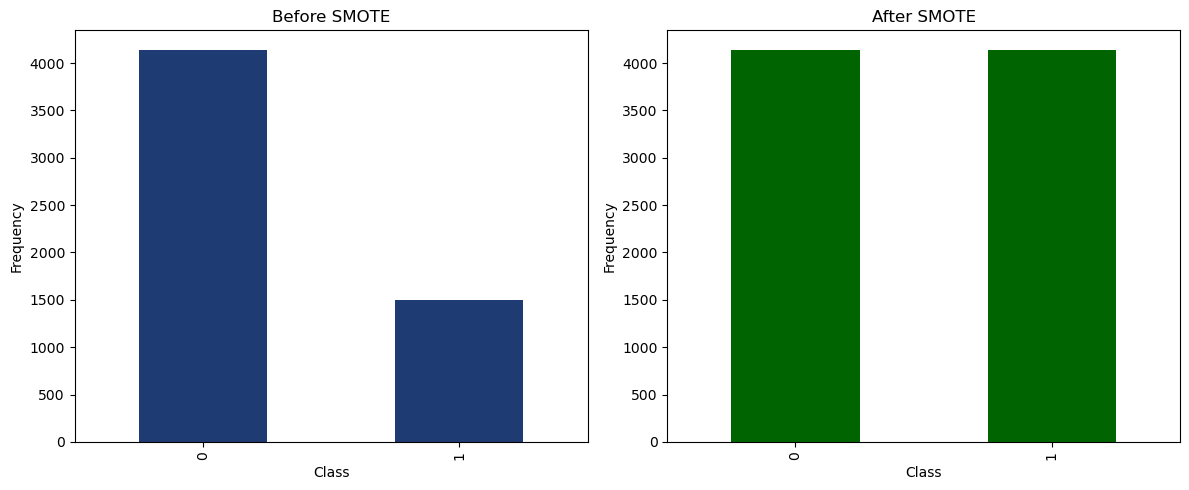

In [223]:
## After SMOTE Frequency 
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Before SMOTE
y_train.value_counts().plot(kind='bar', ax=axes[0], color ="#1F3B73")
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Frequency")

# After SMOTE
y_train_res.value_counts().plot(kind='bar', ax=axes[1], color = "darkgreen")
axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [224]:
## Class Frequency after 

In [225]:
from sklearn.ensemble import RandomForestClassifier

In [226]:
from sklearn.linear_model import LogisticRegression

In [227]:
from sklearn.inspection import permutation_importance

In [228]:
from tqdm import tqdm

In [229]:
## SHAP = Shapley Additive Explanations

import shap

C:\Users\AKILAN M\anaconda3\envs\ds_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Model Parameters

In [230]:
log_model = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, class_weight='balanced')

In [231]:
rf_model = RandomForestClassifier(n_estimators=300,
                                  max_depth=8,                
                                  min_samples_split=10,
                                  min_samples_leaf=5,
                                  max_features='sqrt',
                                  class_weight='balanced',
                                  random_state =42,oob_score = True) 

In [232]:
from xgboost import XGBClassifier

In [233]:
xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1,
    scale_pos_weight=3,
    random_state=42,
    eval_metric="logloss")

In [234]:
from lightgbm import LGBMClassifier

In [235]:
lgb_model = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1,
    class_weight='balanced',
    random_state=42)